# História 2 — Comparativo entre bairros de perfil parecido

Este notebook constrói um agrupamento de bairros do Rio de Janeiro com base em dados da Gabriel. O objetivo é permitir que um morador compare seu bairro com outros bairros de perfil semelhante, em vez de interpretar números isolados.

A análise usa características derivadas de:
- perfil de ocorrências;
- tipos de crime;
- distribuição horária;
- tipo de local;
- sazonalidade;
- presença de Camaleões.

A proposta final é gerar uma tabela bairro → cluster → perfil descritivo e uma função que retorne bairros parecidos para comparação no site público da Gabriel.

In [3]:
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import euclidean_distances

print("Imports OK")

Imports OK


In [5]:
ocorrencias = pd.read_csv("ocorrencias.csv")
sensores = pd.read_csv("sensores.csv")

print(ocorrencias.shape)
print(sensores.shape)

display(ocorrencias.head())
display(sensores.head())

(18894, 19)
(18634, 12)


,IDOcorrencia,NaturezaCrime,CategoriaCrime,SubcategoriaCrime,GeneroLocal,DataOcorrencia,Horario,Intervalo,Latitude,Longitude,Bairro,Zona,Cidade,Estado,Origem,TipoSolicitante,EfetividadeAnalise,EtapaPipeline,TempoParaFechamentoMs
0,2285662795,NaN,Furto,Furto de Veículo,Público,2020-05-17,03h-04h -,03h - 04h,-22.985521,-43.227639,Leblon,Rio de Janeiro - Zona Sul,Rio de Janeiro,RJ,NaN,Funcionário,Não Considerado / Prazo Expirado de Acesso as ...,Concluído,1.161583e+11
1,2285658888,NaN,Furto,Furto de Pertences Pessoais,Público,2020-07-29,01h-02h -,01h - 02h,-22.985873,-43.228362,Leblon,Rio de Janeiro - Zona Sul,Rio de Janeiro,RJ,NaN,Funcionário,Efetiva,Concluído,1.098455e+11
2,2285659292,NaN,Furto,Furto de Pertences Pessoais,Empresarial,2020-08-03,09h-10h -,09h - 10h,-22.985521,-43.227639,Leblon,Rio de Janeiro - Zona Sul,Rio de Janeiro,RJ,NaN,Funcionário,Efetiva,Concluído,1.094135e+11
3,2285646235,NaN,Furto,Furto de Pertences Pessoais,Empresarial,2020-08-07,08h-09h -,08h - 09h,-22.985521,-43.227639,Leblon,Rio de Janeiro - Zona Sul,Rio de Janeiro,RJ,NaN,Funcionário,Efetiva,Concluído,1.090679e+11
4,2285661340,NaN,Segurança Pública,Desordem Pública,Público,2020-08-12,12h-13h -,12h - 13h,-22.985771,-43.228154,Leblon,Rio de Janeiro - Zona Sul,Rio de Janeiro,RJ,NaN,Funcionário,Efetiva,Concluído,1.086359e+11


,IDPontoVisualizacao,IDCamera,IDDispositivo,IDLocal,Latitude,Longitude,Bairro,Zona,Cidade,Estado,StatusConexaoCamera,DataInicioServico
0,f568f9ba-71be-40e1-8ca8-5682f0274552,02f68d5a-1f64-4e13-92ea-310ef4f75d97,36590c05-2b0c-4c1c-a638-ac17c554c1cb,7282,-23.626842,-46.665058,Campo Belo,São Paulo - Zona Sul,São Paulo,SP,Online,2025-09-05T12:50:10
1,886a5614-03d8-4e41-a985-293cb87b3b54,02f920d3-5512-4002-8779-7b2de4ca2106,65439cc8-86c4-4263-acb3-897df07d882e,7696,-22.913168,-43.227771,Maracanã,Rio de Janeiro - Zona Norte,Rio de Janeiro,RJ,Online,2025-11-17T11:59:21
2,aa0bf184-adc2-4857-a570-3b2d6d41940f,030843ec-b032-4226-8220-19f36312ae98,ec287f0c-d0a6-467e-ac24-31227af1b4ad,516,-23.560474,-46.684067,Pinheiros,São Paulo - Zona Oeste,São Paulo,SP,Online,2024-12-19T15:46:16
3,ab991874-d857-490f-8bf5-5a9a9fc5e78e,0312fd95-0d24-4e9b-87f4-7e9658c3d396,2d95aa08-1034-4b3f-a5f7-c060a38dcaa4,5715,-22.925188,-43.232356,Tijuca,Rio de Janeiro - Zona Norte,Rio de Janeiro,RJ,Online,2025-02-27T14:17:46
4,c6a6a1ff-4af6-4cfe-8488-ee303dcbefa4,031415ab-957b-4489-8dfd-bc5eb9d04ea2,c49402f2-8ec4-4064-b367-ecf18bfd6442,454,-22.999719,-43.267920,São Conrado,Rio de Janeiro - Zona Sul,Rio de Janeiro,RJ,Online,2024-07-02T14:10:20


Como o enunciado pede no mínimo uma cidade e cita exemplos do Rio de Janeiro, a análise será feita inicialmente apenas para a cidade do Rio de Janeiro.

In [6]:
occ = ocorrencias[ocorrencias["Cidade"] == "Rio de Janeiro"].copy()
sen = sensores[sensores["Cidade"] == "Rio de Janeiro"].copy()

print("Ocorrências RJ:", occ.shape)
print("Sensores RJ:", sen.shape)

Ocorrências RJ: (12664, 19)
Sensores RJ: (9618, 12)


In [8]:
def normalizar_texto(x):
    if pd.isna(x):
        return None
    x = str(x).strip().upper()
    x = unicodedata.normalize("NFD", x)
    x = "".join(c for c in x if unicodedata.category(c) != "Mn")
    x = re.sub(r"\s+", " ", x)
    return x

occ["bairro_norm"] = occ["Bairro"].apply(normalizar_texto)
sen["bairro_norm"] = sen["Bairro"].apply(normalizar_texto)

occ[["Bairro", "bairro_norm"]].drop_duplicates().head()

,Bairro,bairro_norm
0,Leblon,LEBLON
7,Ipanema,IPANEMA
87,Lagoa,LAGOA
94,Copacabana,COPACABANA
112,São Conrado,SAO CONRADO


In [9]:
def extrair_hora(x):
    if pd.isna(x):
        return np.nan
    match = re.search(r"(\d{1,2})", str(x))
    if match:
        hora = int(match.group(1))
        if 0 <= hora <= 23:
            return hora
    return np.nan

def periodo_do_dia(h):
    if pd.isna(h):
        return "sem_horario"
    if 0 <= h <= 5:
        return "madrugada"
    elif 6 <= h <= 11:
        return "manha"
    elif 12 <= h <= 17:
        return "tarde"
    else:
        return "noite"
    
occ["hora"] = occ["Horario"].apply(extrair_hora)
occ["periodo"] = occ["hora"].apply(periodo_do_dia)

occ[["Horario", "hora", "periodo"]].head()

,Horario,hora,periodo
0,03h-04h -,3.0,madrugada
1,01h-02h -,1.0,madrugada
2,09h-10h -,9.0,manha
3,08h-09h -,8.0,manha
4,12h-13h -,12.0,tarde


In [13]:
occ["data"] = pd.to_datetime(occ["DataOcorrencia"], errors="coerce")
occ["ano_mes"] = occ["data"].dt.to_period("M").astype(str)

base = occ.groupby("bairro_norm").agg(
    bairro=("Bairro", "first"),
    zona=("Zona", "first"),
    total_ocorrencias=("IDOcorrencia", "nunique"),
    meses_ativos=("ano_mes", "nunique")
).reset_index()

base["ocorrencias_por_mes"] = (
    base["total_ocorrencias"] / base["meses_ativos"].replace(0, np.nan)
).fillna(0)

base

,bairro_norm,bairro,zona,total_ocorrencias,meses_ativos,ocorrencias_por_mes
0,ABOLICAO,Abolição,Rio de Janeiro - Zona Norte,3,2,1.500000
1,AGUA SANTA,Água Santa,Rio de Janeiro - Zona Norte,7,7,1.000000
2,ALTO DA BOA VISTA,Alto da Boa Vista,Rio de Janeiro - Zona Norte,18,10,1.800000
3,ANCHIETA,Anchieta,Rio de Janeiro - Zona Norte,1,1,1.000000
4,ANDARAI,Andaraí,Rio de Janeiro - Zona Norte,95,30,3.166667
...,...,...,...,...,...,...
109,VILA DA PENHA,Vila da Penha,Rio de Janeiro - Zona Norte,7,7,1.000000
110,VILA GOMES CARDIM,Vila Gomes Cardim,Rio de Janeiro - Resto do Estado,1,1,1.000000
111,VILA ISABEL,Vila Isabel,Rio de Janeiro - Zona Norte,214,32,6.687500
112,VILA MILITAR,Vila Militar,Rio de Janeiro - Zona Oeste,1,1,1.000000


In [14]:
crime_pct = pd.crosstab(
    occ["bairro_norm"],
    occ["CategoriaCrime"],
    normalize="index"
).add_prefix("pct_crime_").reset_index()

crime_pct

CategoriaCrime,bairro_norm,pct_crime_Acidentes de Trânsito,pct_crime_Crimes Sexuais,pct_crime_Crimes contra Vulneráveis,pct_crime_Erro,pct_crime_Furto,pct_crime_Golpes e Fraudes,pct_crime_Invasão,pct_crime_Ocorrências Não Criminais,pct_crime_Outros,pct_crime_Roubo,pct_crime_Roubo a Estabelecimento,pct_crime_Roubo a Residência,pct_crime_Segurança Pública,pct_crime_Solicitações Administrativas,pct_crime_Tentativas,pct_crime_Vandalismo e Danos,pct_crime_Violência e Ameaça
0,ABOLICAO,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.666667
1,AGUA SANTA,0.200000,0.000000,0.0,0.000000,0.400000,0.000000,0.000000,0.000000,0.000000,0.200000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.200000
2,ALTO DA BOA VISTA,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.666667,0.0,0.0,0.000000,0.055556,0.166667,0.000000,0.111111
3,ANCHIETA,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1.000000,0.000000,0.000000
4,ANDARAI,0.168421,0.021053,0.0,0.000000,0.210526,0.031579,0.000000,0.000000,0.010526,0.242105,0.0,0.0,0.021053,0.052632,0.147368,0.052632,0.042105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,VILA DA PENHA,0.166667,0.000000,0.0,0.000000,0.166667,0.000000,0.000000,0.000000,0.000000,0.500000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.166667
109,VILA GOMES CARDIM,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1.000000,0.000000,0.000000,0.000000
110,VILA ISABEL,0.105263,0.004785,0.0,0.004785,0.248804,0.014354,0.033493,0.009569,0.014354,0.263158,0.0,0.0,0.000000,0.057416,0.162679,0.033493,0.047847
111,VILA MILITAR,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.000000


In [15]:
local_pct = pd.crosstab(
    occ["bairro_norm"],
    occ["GeneroLocal"],
    normalize="index"
).add_prefix("pct_local_").reset_index()

local_pct

GeneroLocal,bairro_norm,pct_local_Empresarial,pct_local_Público,pct_local_Residencial
0,ABOLICAO,0.000000,1.000000,0.000000
1,AGUA SANTA,0.000000,0.400000,0.600000
2,ALTO DA BOA VISTA,0.000000,0.888889,0.111111
3,ANCHIETA,0.000000,1.000000,0.000000
4,ANDARAI,0.040541,0.770270,0.189189
...,...,...,...,...
104,VIDIGAL,0.142857,0.714286,0.142857
105,VILA DA PENHA,0.000000,0.500000,0.500000
106,VILA GOMES CARDIM,0.000000,1.000000,0.000000
107,VILA ISABEL,0.015707,0.623037,0.361257


In [16]:
periodo_pct = pd.crosstab(
    occ["bairro_norm"],
    occ["periodo"],
    normalize="index"
).add_prefix("pct_periodo_").reset_index()

periodo_pct

periodo,bairro_norm,pct_periodo_madrugada,pct_periodo_manha,pct_periodo_noite,pct_periodo_sem_horario,pct_periodo_tarde
0,ABOLICAO,0.666667,0.333333,0.000000,0.000000,0.000000
1,AGUA SANTA,0.142857,0.571429,0.142857,0.000000,0.142857
2,ALTO DA BOA VISTA,0.111111,0.055556,0.722222,0.000000,0.111111
3,ANCHIETA,0.000000,0.000000,1.000000,0.000000,0.000000
4,ANDARAI,0.252632,0.126316,0.431579,0.031579,0.157895
...,...,...,...,...,...,...
109,VILA DA PENHA,0.000000,0.428571,0.428571,0.142857,0.000000
110,VILA GOMES CARDIM,0.000000,0.000000,0.000000,1.000000,0.000000
111,VILA ISABEL,0.257009,0.070093,0.350467,0.056075,0.266355
112,VILA MILITAR,0.000000,0.000000,0.000000,0.000000,1.000000


In [17]:
mensal = occ.groupby(["bairro_norm", "ano_mes"]).size().reset_index(name="qtd")

sazonalidade = mensal.groupby("bairro_norm")["qtd"].agg(
    media_mensal="mean",
    desvio_mensal="std"
).reset_index()

sazonalidade["variacao_mensal"] = (
    sazonalidade["desvio_mensal"] / sazonalidade["media_mensal"]
).fillna(0)

sazonalidade

,bairro_norm,media_mensal,desvio_mensal,variacao_mensal
0,ABOLICAO,1.500000,0.707107,0.471405
1,AGUA SANTA,1.000000,0.000000,0.000000
2,ALTO DA BOA VISTA,1.800000,1.619328,0.899627
3,ANCHIETA,1.000000,NaN,0.000000
4,ANDARAI,3.166667,2.364731,0.746757
...,...,...,...,...
109,VILA DA PENHA,1.000000,0.000000,0.000000
110,VILA GOMES CARDIM,1.000000,NaN,0.000000
111,VILA ISABEL,6.656250,3.525112,0.529594
112,VILA MILITAR,1.000000,NaN,0.000000


In [19]:
sensores_bairro = sen.groupby("bairro_norm").agg(
    camaleoes_total=("IDDispositivo", "nunique")
).reset_index()

sensores_bairro

,bairro_norm,camaleoes_total
0,ABOLICAO,1
1,AGUA SANTA,2
2,ALTO DA BOA VISTA,7
3,ANDARAI,32
4,ANIL,11
...,...,...
87,VARGEM PEQUENA,15
88,VASCO DA GAMA,6
89,VILA DA PENHA,1
90,VILA ISABEL,77


In [20]:
df = base.merge(crime_pct, on="bairro_norm", how="left")
df = df.merge(local_pct, on="bairro_norm", how="left")
df = df.merge(periodo_pct, on="bairro_norm", how="left")
df = df.merge(sazonalidade, on="bairro_norm", how="left")
df = df.merge(sensores_bairro, on="bairro_norm", how="left")

df = df.fillna(0)

df["ocorrencias_por_camaleao"] = (
    df["total_ocorrencias"] / df["camaleoes_total"].replace(0, np.nan)
).fillna(0)

df

,bairro_norm,bairro,zona,total_ocorrencias,meses_ativos,ocorrencias_por_mes,pct_crime_Acidentes de Trânsito,pct_crime_Crimes Sexuais,pct_crime_Crimes contra Vulneráveis,pct_crime_Erro,...,pct_periodo_madrugada,pct_periodo_manha,pct_periodo_noite,pct_periodo_sem_horario,pct_periodo_tarde,media_mensal,desvio_mensal,variacao_mensal,camaleoes_total,ocorrencias_por_camaleao
0,ABOLICAO,Abolição,Rio de Janeiro - Zona Norte,3,2,1.500000,0.000000,0.000000,0.0,0.000000,...,0.666667,0.333333,0.000000,0.000000,0.000000,1.500000,0.707107,0.471405,1.0,3.000000
1,AGUA SANTA,Água Santa,Rio de Janeiro - Zona Norte,7,7,1.000000,0.200000,0.000000,0.0,0.000000,...,0.142857,0.571429,0.142857,0.000000,0.142857,1.000000,0.000000,0.000000,2.0,3.500000
2,ALTO DA BOA VISTA,Alto da Boa Vista,Rio de Janeiro - Zona Norte,18,10,1.800000,0.000000,0.000000,0.0,0.000000,...,0.111111,0.055556,0.722222,0.000000,0.111111,1.800000,1.619328,0.899627,7.0,2.571429
3,ANCHIETA,Anchieta,Rio de Janeiro - Zona Norte,1,1,1.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.000000
4,ANDARAI,Andaraí,Rio de Janeiro - Zona Norte,95,30,3.166667,0.168421,0.021053,0.0,0.000000,...,0.252632,0.126316,0.431579,0.031579,0.157895,3.166667,2.364731,0.746757,32.0,2.968750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,VILA DA PENHA,Vila da Penha,Rio de Janeiro - Zona Norte,7,7,1.000000,0.166667,0.000000,0.0,0.000000,...,0.000000,0.428571,0.428571,0.142857,0.000000,1.000000,0.000000,0.000000,1.0,7.000000
110,VILA GOMES CARDIM,Vila Gomes Cardim,Rio de Janeiro - Resto do Estado,1,1,1.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.000000
111,VILA ISABEL,Vila Isabel,Rio de Janeiro - Zona Norte,214,32,6.687500,0.105263,0.004785,0.0,0.004785,...,0.257009,0.070093,0.350467,0.056075,0.266355,6.656250,3.525112,0.529594,77.0,2.779221
112,VILA MILITAR,Vila Militar,Rio de Janeiro - Zona Oeste,1,1,1.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,0.000000


In [21]:
df_modelo = df[
    (df["total_ocorrencias"] >= 30) &
    (df["camaleoes_total"] >= 3)
].copy()

print("Bairros usados no modelo:", df_modelo.shape[0])
df_modelo[["bairro", "total_ocorrencias", "camaleoes_total"]].sort_values(
    "total_ocorrencias", ascending=False
).head(10)

Bairros usados no modelo: 44


,bairro,total_ocorrencias,camaleoes_total
29,Copacabana,1565,342.0
50,Ipanema,1299,445.0
101,Tijuca,1249,310.0
63,Leblon,1160,384.0
7,Barra da Tijuca,814,618.0
11,Botafogo,626,210.0
39,Flamengo,492,134.0
60,Lagoa,469,166.0
56,Jardim Botânico,447,222.0
69,Maracanã,364,72.0


Bairros com poucas ocorrências ou pouquíssimos Camaleões podem gerar agrupamentos instáveis. Por isso, foram mantidos apenas bairros com volume mínimo de dados.

In [22]:
feature_cols = [
    "total_ocorrencias",
    "ocorrencias_por_mes",
    "camaleoes_total",
    "ocorrencias_por_camaleao",
    "variacao_mensal",
    "pct_periodo_madrugada",
    "pct_periodo_manha",
    "pct_periodo_tarde",
    "pct_periodo_noite",
]

feature_cols += [c for c in df_modelo.columns if c.startswith("pct_crime_")]
feature_cols += [c for c in df_modelo.columns if c.startswith("pct_local_")]

feature_cols = list(dict.fromkeys(feature_cols))

X = df_modelo[feature_cols]

print(feature_cols)

['total_ocorrencias', 'ocorrencias_por_mes', 'camaleoes_total', 'ocorrencias_por_camaleao', 'variacao_mensal', 'pct_periodo_madrugada', 'pct_periodo_manha', 'pct_periodo_tarde', 'pct_periodo_noite', 'pct_crime_Acidentes de Trânsito', 'pct_crime_Crimes Sexuais', 'pct_crime_Crimes contra Vulneráveis', 'pct_crime_Erro', 'pct_crime_Furto', 'pct_crime_Golpes e Fraudes', 'pct_crime_Invasão', 'pct_crime_Ocorrências Não Criminais', 'pct_crime_Outros', 'pct_crime_Roubo', 'pct_crime_Roubo a Estabelecimento', 'pct_crime_Roubo a Residência', 'pct_crime_Segurança Pública', 'pct_crime_Solicitações Administrativas', 'pct_crime_Tentativas', 'pct_crime_Vandalismo e Danos', 'pct_crime_Violência e Ameaça', 'pct_local_Empresarial', 'pct_local_Público', 'pct_local_Residencial']


In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
scores = []

for k in range(3, 8):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = modelo.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append({"k": k, "silhouette": score})

scores_df = pd.DataFrame(scores)
scores_df

,k,silhouette
0,3,0.178413
1,4,0.089820
2,5,0.096698
3,6,0.104089
4,7,0.083604


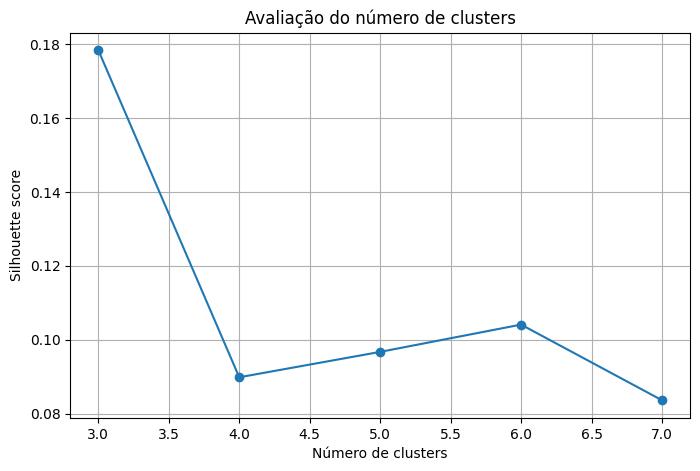

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(scores_df["k"], scores_df["silhouette"], marker="o")
plt.title("Avaliação do número de clusters")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

In [26]:
k_final = 4

modelo_final = KMeans(n_clusters=k_final, random_state=42, n_init=20)
df_modelo["cluster_id"] = modelo_final.fit_predict(X_scaled)

df_modelo[["bairro", "cluster_id", "total_ocorrencias", "camaleoes_total"]].head()

,bairro,cluster_id,total_ocorrencias,camaleoes_total
4,Andaraí,0,95,32.0
7,Barra da Tijuca,1,814,618.0
8,Barra Olímpica,0,117,55.0
11,Botafogo,1,626,210.0
13,Cachambi,2,115,34.0


In [27]:
perfil_clusters = df_modelo.groupby("cluster_id")[feature_cols].mean()
perfil_clusters

,total_ocorrencias,ocorrencias_por_mes,camaleoes_total,ocorrencias_por_camaleao,variacao_mensal,pct_periodo_madrugada,pct_periodo_manha,pct_periodo_tarde,pct_periodo_noite,pct_crime_Acidentes de Trânsito,...,pct_crime_Roubo a Estabelecimento,pct_crime_Roubo a Residência,pct_crime_Segurança Pública,pct_crime_Solicitações Administrativas,pct_crime_Tentativas,pct_crime_Vandalismo e Danos,pct_crime_Violência e Ameaça,pct_local_Empresarial,pct_local_Público,pct_local_Residencial
cluster_id,,,,,,,,,,,,,,,,,,,,,
0,93.687500,3.888916,50.812500,2.307884,0.604778,0.171922,0.197498,0.229107,0.356646,0.161352,...,0.000000,0.00000,0.012139,0.051551,0.162605,0.050368,0.045676,0.028775,0.647066,0.324158
1,872.111111,16.600434,308.333333,2.944714,0.571080,0.197845,0.172392,0.274510,0.312479,0.076903,...,0.000000,0.00009,0.008028,0.032716,0.147063,0.027027,0.025860,0.061915,0.713171,0.224914
2,151.777778,4.460326,45.944444,3.667606,0.628969,0.277662,0.129347,0.224533,0.290741,0.086104,...,0.000228,0.00000,0.002304,0.037919,0.166350,0.043751,0.034934,0.027313,0.693136,0.279551
3,34.000000,2.125000,7.000000,4.857143,1.405214,0.147059,0.117647,0.411765,0.205882,0.266667,...,0.000000,0.00000,0.000000,0.000000,0.100000,0.333333,0.066667,0.000000,0.406250,0.593750


In [28]:
descricoes = {
    0: "Bairros com atividade moderada, perfil misto e ocorrências distribuídas ao longo do dia.",
    1: "Bairros urbanos intensos, com alto volume de ocorrências e forte presença de Camaleões.",
    2: "Bairros residenciais ou de menor movimento, com volume mais baixo de ocorrências.",
    3: "Bairros com atividade recorrente em áreas públicas e maior concentração em determinados horários."
}

df_modelo["perfil_descritivo"] = df_modelo["cluster_id"].map(descricoes)

In [29]:
def bairros_parecidos(nome_bairro, df_modelo, X_scaled, n=5):
    bairro_norm = normalizar_texto(nome_bairro)

    if bairro_norm not in df_modelo["bairro_norm"].values:
        return f"Bairro '{nome_bairro}' não encontrado no modelo."

    pos_bairro = df_modelo.index[df_modelo["bairro_norm"] == bairro_norm][0]
    cluster = df_modelo.loc[pos_bairro, "cluster_id"]

    candidatos = df_modelo[
        (df_modelo["cluster_id"] == cluster) &
        (df_modelo["bairro_norm"] != bairro_norm)
    ].copy()

    idx_bairro = df_modelo.index.get_loc(pos_bairro)
    idx_candidatos = [df_modelo.index.get_loc(i) for i in candidatos.index]

    distancias = euclidean_distances(
        X_scaled[idx_bairro].reshape(1, -1),
        X_scaled[idx_candidatos]
    )[0]

    candidatos["distancia"] = distancias

    return candidatos.sort_values("distancia").head(n)[[
        "bairro",
        "cluster_id",
        "perfil_descritivo",
        "total_ocorrencias",
        "ocorrencias_por_mes",
        "camaleoes_total",
        "distancia"
    ]]
    
bairros_parecidos("Tijuca", df_modelo, X_scaled, n=5)

,bairro,cluster_id,perfil_descritivo,total_ocorrencias,ocorrencias_por_mes,camaleoes_total,distancia
11,Botafogo,1,"Bairros urbanos intensos, com alto volume de o...",626,12.274510,210.0,7.999738
29,Copacabana,1,"Bairros urbanos intensos, com alto volume de o...",1565,27.456140,342.0,8.179072
50,Ipanema,1,"Bairros urbanos intensos, com alto volume de o...",1299,18.826087,445.0,8.451522
63,Leblon,1,"Bairros urbanos intensos, com alto volume de o...",1160,16.111111,384.0,8.555379
7,Barra da Tijuca,1,"Bairros urbanos intensos, com alto volume de o...",814,24.666667,618.0,8.599041


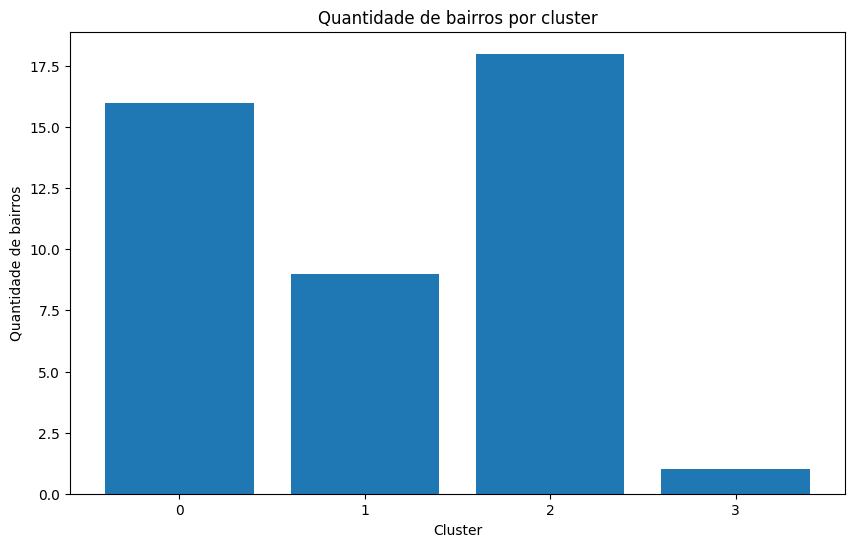

In [30]:
plt.figure(figsize=(10, 6))

contagem = df_modelo["cluster_id"].value_counts().sort_index()

plt.bar(contagem.index.astype(str), contagem.values)
plt.title("Quantidade de bairros por cluster")
plt.xlabel("Cluster")
plt.ylabel("Quantidade de bairros")
plt.show()

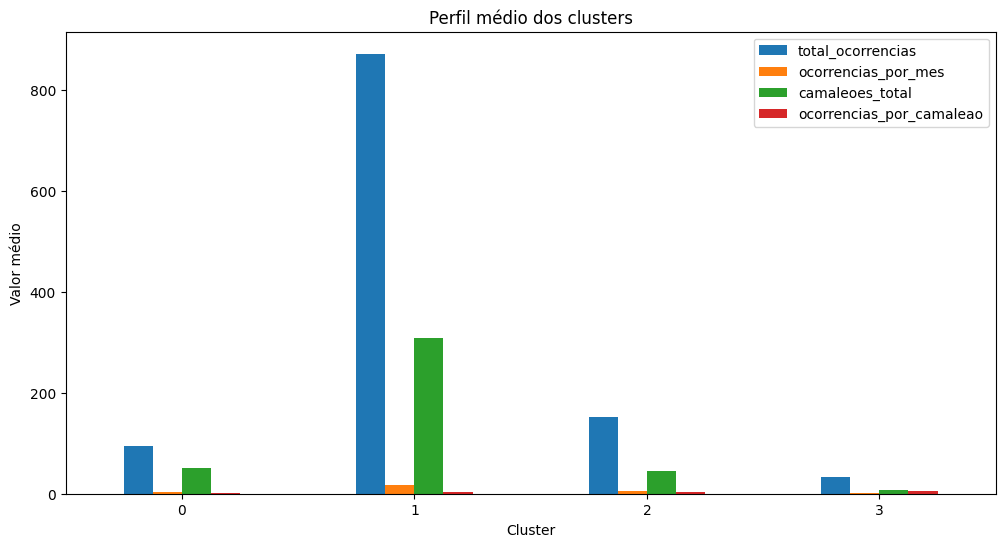

In [31]:
resumo_cluster = df_modelo.groupby("cluster_id")[[
    "total_ocorrencias",
    "ocorrencias_por_mes",
    "camaleoes_total",
    "ocorrencias_por_camaleao"
]].mean()

resumo_cluster.plot(kind="bar", figsize=(12, 6))
plt.title("Perfil médio dos clusters")
plt.xlabel("Cluster")
plt.ylabel("Valor médio")
plt.xticks(rotation=0)
plt.show()

In [33]:
saida = df_modelo[[
    "bairro",
    "bairro_norm",
    "zona",
    "cluster_id",
    "perfil_descritivo",
    "total_ocorrencias",
    "ocorrencias_por_mes",
    "camaleoes_total"
]]

saida.to_csv("bairro_cluster_perfil.csv", index=False)

saida

,bairro,bairro_norm,zona,cluster_id,perfil_descritivo,total_ocorrencias,ocorrencias_por_mes,camaleoes_total
4,Andaraí,ANDARAI,Rio de Janeiro - Zona Norte,0,"Bairros com atividade moderada, perfil misto e...",95,3.166667,32.0
7,Barra da Tijuca,BARRA DA TIJUCA,Rio de Janeiro - Zona Oeste,1,"Bairros urbanos intensos, com alto volume de o...",814,24.666667,618.0
8,Barra Olímpica,BARRA OLIMPICA,Rio de Janeiro - Zona Oeste,0,"Bairros com atividade moderada, perfil misto e...",117,4.875000,55.0
11,Botafogo,BOTAFOGO,Rio de Janeiro - Zona Sul,1,"Bairros urbanos intensos, com alto volume de o...",626,12.274510,210.0
13,Cachambi,CACHAMBI,Rio de Janeiro - Zona Norte,2,"Bairros residenciais ou de menor movimento, co...",115,4.791667,34.0
22,Catete,CATETE,Rio de Janeiro - Zona Sul,2,"Bairros residenciais ou de menor movimento, co...",69,2.300000,22.0
25,Centro,CENTRO,Rio de Janeiro - Centro,2,"Bairros residenciais ou de menor movimento, co...",229,6.939394,131.0
29,Copacabana,COPACABANA,Rio de Janeiro - Zona Sul,1,"Bairros urbanos intensos, com alto volume de o...",1565,27.456140,342.0
33,Del Castilho,DEL CASTILHO,Rio de Janeiro - Zona Norte,0,"Bairros com atividade moderada, perfil misto e...",37,1.850000,7.0
36,Engenho de Dentro,ENGENHO DE DENTRO,Rio de Janeiro - Zona Norte,0,"Bairros com atividade moderada, perfil misto e...",62,3.263158,13.0


## Limitações

Esta análise é exploratória e depende dos dados disponíveis da Gabriel. Como a presença de Camaleões não é distribuída de forma uniforme pela cidade, bairros com maior cobertura podem apresentar mais ocorrências registradas, não necessariamente mais criminalidade real.

Além disso, nesta versão inicial o agrupamento usa principalmente dados Gabriel. Para tornar a comparação mais adequada para o morador, o próximo passo é incorporar dados socioeconômicos do Censo 2022, como renda, população, densidade demográfica e perfil dos domicílios.

O clustering não define se um bairro é seguro ou perigoso. Ele apenas agrupa bairros com padrões semelhantes dentro das variáveis analisadas. A interpretação final deve ser feita com cuidado, evitando linguagem alarmista.

## Conclusão

O notebook construiu um pipeline reproduzível para agrupar bairros do Rio de Janeiro segundo padrões de ocorrência, horário, tipo de local, sazonalidade e presença de Camaleões.

O resultado permite consultar bairros parecidos com um bairro de interesse e gerar uma comparação mais justa para o usuário final do site público da Gabriel.

Como próximo passo, recomenda-se integrar dados do Censo IBGE 2022 para melhorar a similaridade socioeconômica entre os bairros comparados.